In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("sim_merged_datasets_co_mo.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 8000 × 60
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [2]:
gl_source = ['g0', 'g1', 'g2', 'g3']
#gl_source = ['g0', 'g1', 'g3']

gl_recv = ['g5', 'g6', 'g7']

In [3]:
from scipy.sparse import issparse

ict1 = (adata.obs["CellType"] == 'CellType1') & (adata.obs['Batch2'] == 'Co')
ict2 = (adata.obs["CellType"] == 'CellType2') & (adata.obs['Batch2'] == 'Co')

adata_ct1_co = adata[ict1, gl_source].copy()
adata_ct2_co = adata[ict2, gl_recv].copy()
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)


AnnData object with n_obs × n_vars = 2000 × 4
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [4]:

ict1 = (adata.obs["CellType"] == 'CellType1') & (adata.obs['Batch2'] == 'Mo')
ict2 = (adata.obs["CellType"] == 'CellType2') & (adata.obs['Batch2'] == 'Mo')

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2000 × 4
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
View of AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'


In [5]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

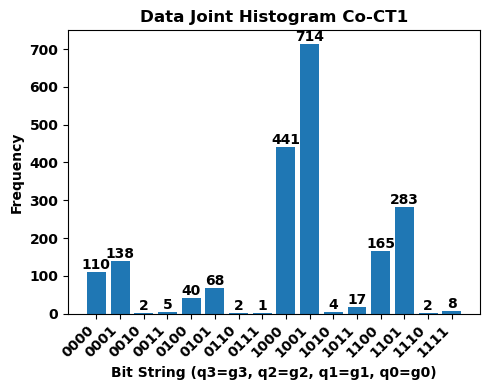

Joint Counts: Counter({'1001': 714, '1000': 441, '1101': 283, '1100': 165, '0001': 138, '0000': 110, '0101': 68, '0100': 40, '1011': 17, '1111': 8, '0011': 5, '1010': 4, '0010': 2, '1110': 2, '0110': 2, '0111': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [6]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_co_ct1.svg', title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

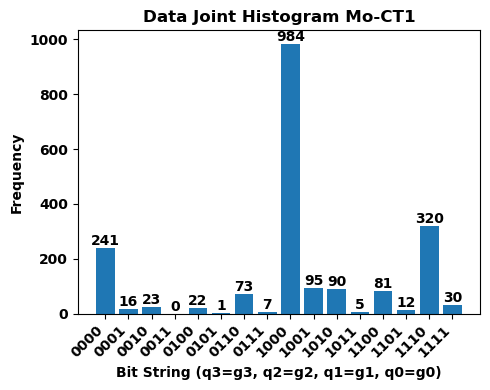

Joint Counts: Counter({'1000': 984, '1110': 320, '0000': 241, '1001': 95, '1010': 90, '1100': 81, '0110': 73, '1111': 30, '0010': 23, '0100': 22, '0001': 16, '1101': 12, '0111': 7, '1011': 5, '0101': 1})
Bit Strings: ['0000', '0001', '0010', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [7]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_mo_ct1.svg', title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

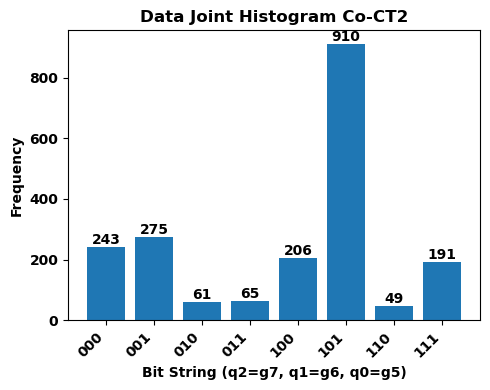

Joint Counts: Counter({'101': 910, '001': 275, '000': 243, '100': 206, '111': 191, '011': 65, '010': 61, '110': 49})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [8]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_co_ct2.svg', title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

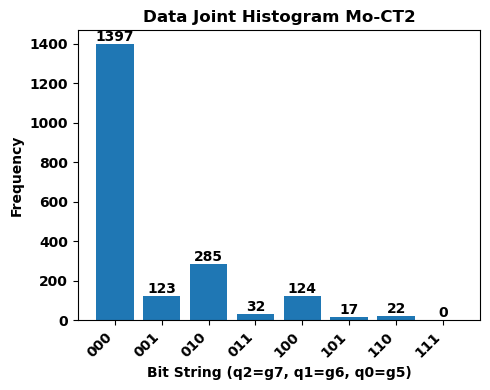

Joint Counts: Counter({'000': 1397, '010': 285, '100': 124, '001': 123, '011': 32, '110': 22, '101': 17})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110']


In [9]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_mo_ct2.svg', title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [10]:
from quantum_functions import vector_normalize_dictionary_values, create_initial_circuit2

import numpy as np
# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'1000': 984, '1110': 320, '0000': 241, '1001': 95, '1010': 90, '1100': 81, '0110': 73, '1111': 30, '0010': 23, '0100': 22, '0001': 16, '1101': 12, '0111': 7, '1011': 5, '0101': 1})
State Set CT2 MO: Counter({'000': 1397, '010': 285, '100': 124, '001': 123, '011': 32, '110': 22, '101': 17})
Interacted State Set CT1 CO: Counter({'1001': 714, '1000': 441, '1101': 283, '1100': 165, '0001': 138, '0000': 110, '0101': 68, '0100': 40, '1011': 17, '1111': 8, '0011': 5, '1010': 4, '0010': 2, '1110': 2, '0110': 2, '0111': 1})
Interacted State Set CT2 CO: Counter({'101': 910, '001': 275, '000': 243, '100': 206, '111': 191, '011': 65, '010': 61, '110': 49})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'1000': 0.9135659365154415, '0000': 0.2237493807929079, '0111': 0.006498944670333425, '1101': 0.011141048006285872, '1111': 0.027852620015714678, '0001': 0.014854730675047828, '1010': 0.083557860

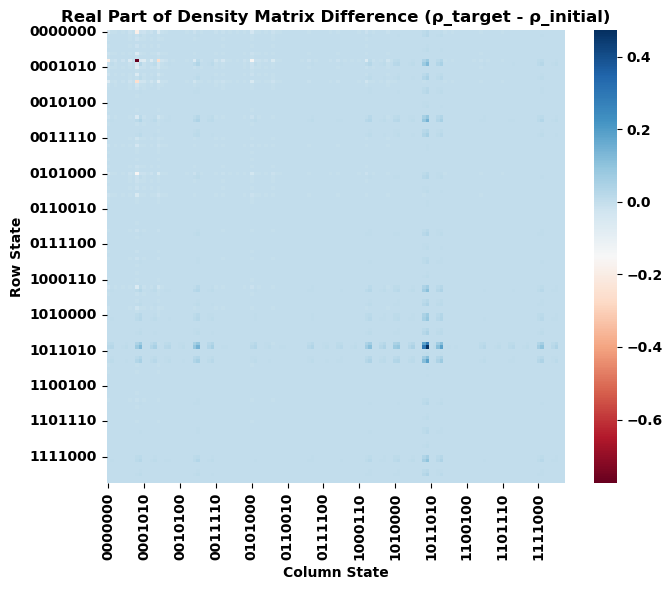


--- CNOT Candidate Analysis Summary ---
System has 7 qubits.
Total possible CNOTs (brute-force): 42
Number of refined CNOT candidates found: 6
---------------------------------------

{'max_element': 0.47244570832052063, 'min_element': -0.7758702081219088, 'abs_average': 0.0014004900968917506, 'avg_positive': 0.0014158603225045382, 'avg_negative': -0.0013575132936723066}


In [11]:
from quantum_functions import find_cnot_candidates_from_state_diff
thresh = 0.3
# --- State and Density Matrix Analysis ---
initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
    normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co,
    threshold = thresh, show_plot = True, verbose_print = True)

print(stats)


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---


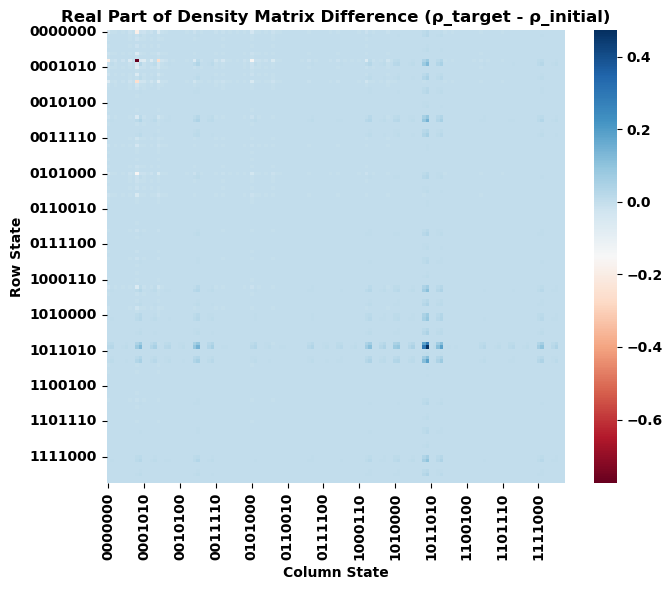


--- CNOT Candidate Analysis Summary ---
System has 7 qubits.
Total possible CNOTs (brute-force): 42
Number of refined CNOT candidates found: 6
---------------------------------------

Number of initial CNOT candidates: 6
Initial KL-divergence: 4.756499
  - Starting CNOT search -
  - No. tested pairs: 30 | Added CNOTs [(3, 6), (3, 4)] | Best pair KL sum: 2.078516
  - No. CNOT tested insertion: 6 | Added CNOT (0, 3) at index 0 | Best added KL sum: 4.733437
  - Single CNOT insertion did not improve upon the best pair.
   - Cannot perform deletion on an empty sequence.
  - Adopted new sequence. New KL Sum: 2.078516
  - No. tested pairs: 12 | Added CNOTs [(0, 3), (3, 0)] | Best pair KL sum: 1.071823
  - No. CNOT tested insertion: 12 | Added CNOT (3, 0) at index 0 | Best added KL sum: 1.032595
  - Best single CNOT insertion KL Sum: 1.032595
  - No. CNOT tested deletion: 2. Deletion did not improve KL sum.
  - Adopted new sequence. New KL Sum: 1.032595
  - No. tested pairs: 6 | No added CNOT

In [12]:
from quantum_functions import find_best_cnot_sequence_iterative_n_wise, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)

# Single insertion can be insertion or deletation of CX (something failing with the update criteria)
all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh,
    nchoose=2,
    kl_tol = 0.5, 
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'1001': 4181, '0110': 21, '1111': 437, '0000': 239, '1011': 35, '1101': 26, '1000': 51, '0100': 3, '1110': 2, '0010': 3, '0001': 1, '1100': 1}
Counts for c_measure2: {'101': 4475, '111': 179, '000': 245, '001': 46, '100': 39, '010': 11, '110': 2, '011': 3}


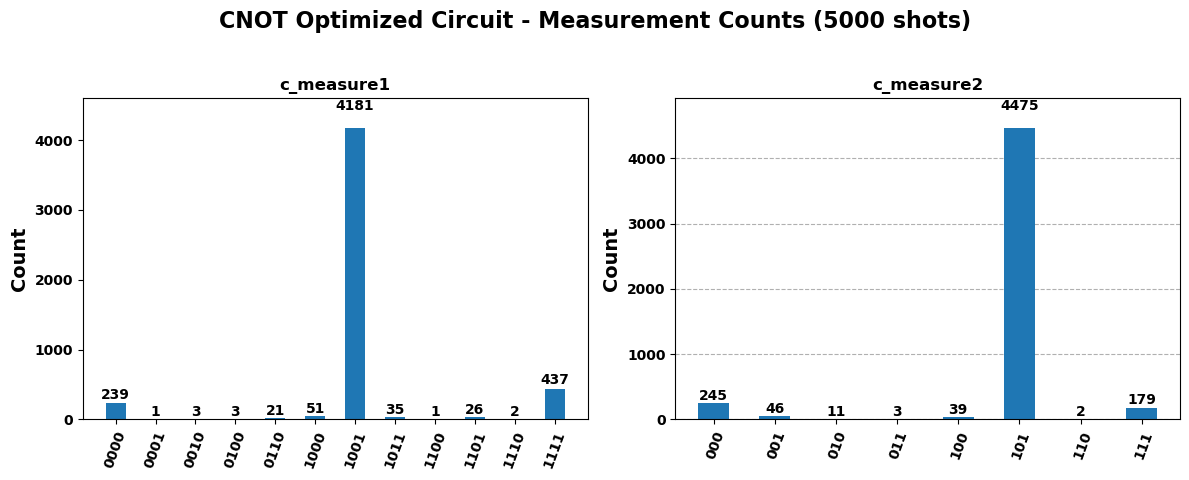

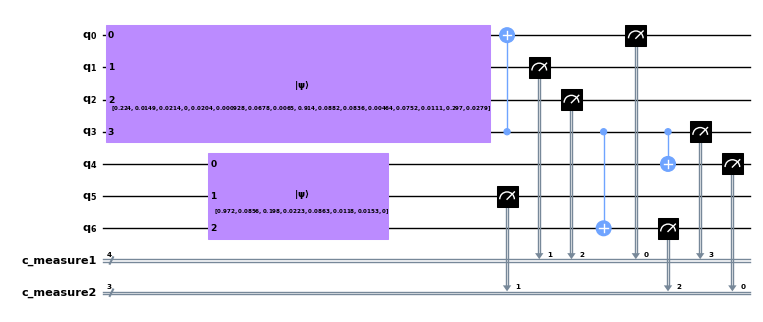

In [14]:
from quantum_functions import plot_measurement_histograms

measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

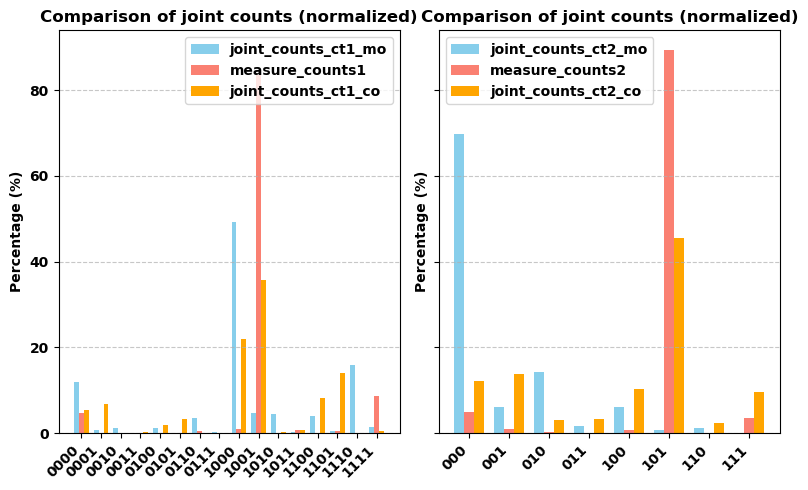

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---

--- Generating CNOT candidates from density matrix difference. ---


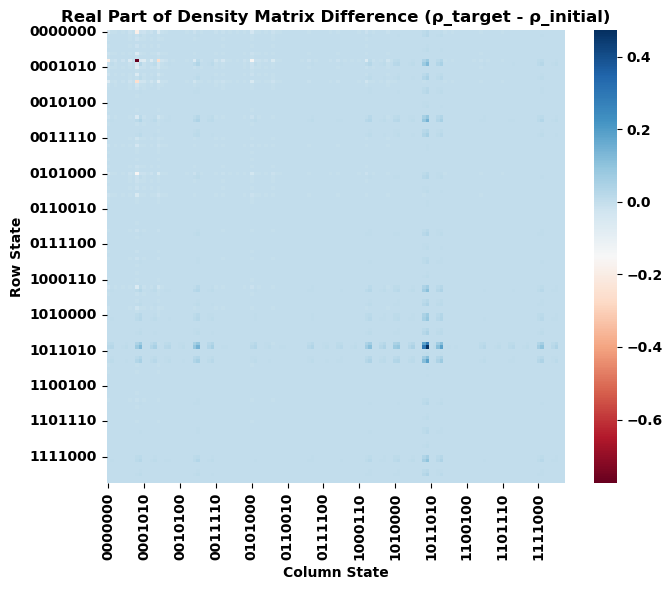


--- CNOT Candidate Analysis Summary ---
System has 7 qubits.
Total possible CNOTs (brute-force): 42
Number of refined CNOT candidates found: 6
---------------------------------------

Initial KL divergence (baseline): 4.777579

--- Starting Epoch 1/6 (Addition) with CNOT: (4, 3) (KL: 4.751435) ---
    --> Found a better KL on this path: 3.747044 at depth 2 with added CNOT (3, 0)
    --> Found a better KL on this path: 3.286197 at depth 3 with added CNOT (3, 4)
    --> Found a better KL on this path: 1.086844 at depth 4 with added CNOT (3, 6)
  Epoch 1 best KL Sum: 1.086844
  --> Epoch 1 found a new overall best KL Sum: 1.086844

--- Starting Epoch 2/6 (Addition) with CNOT: (0, 3) (KL: 4.856697) ---
  Skipping epoch: Single CNOT KL (4.856697) does not improve over baseline (4.777579).

--- Starting Epoch 3/6 (Addition) with CNOT: (3, 0) (KL: 3.766763) ---
    --> Found a better KL on this path: 3.251826 at depth 2 with added CNOT (3, 4)
    --> Found a better KL on this path: 1.030677 

In [16]:
from quantum_functions import find_best_cnot_sequence_multi_epoch

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 40
min_greedy_depth = 2

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold = thresh,
    kl_tol = 0.1,
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'1001': 4155, '1111': 465, '1000': 46, '0000': 249, '1011': 33, '1101': 22, '0110': 19, '0001': 5, '1110': 4, '0010': 2}
Counts for c_measure2: {'101': 4452, '100': 40, '000': 266, '111': 184, '010': 5, '001': 48, '011': 2, '110': 3}


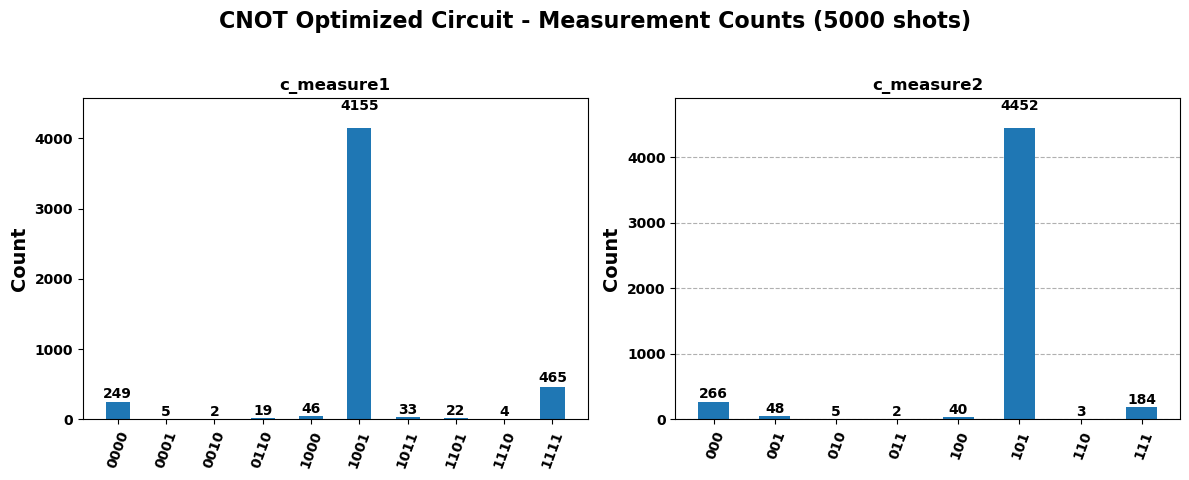

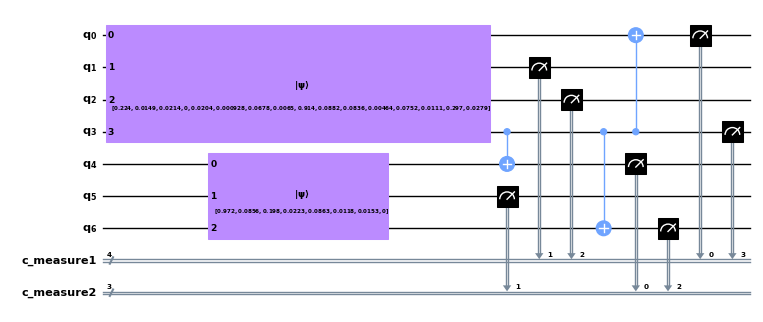

In [17]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

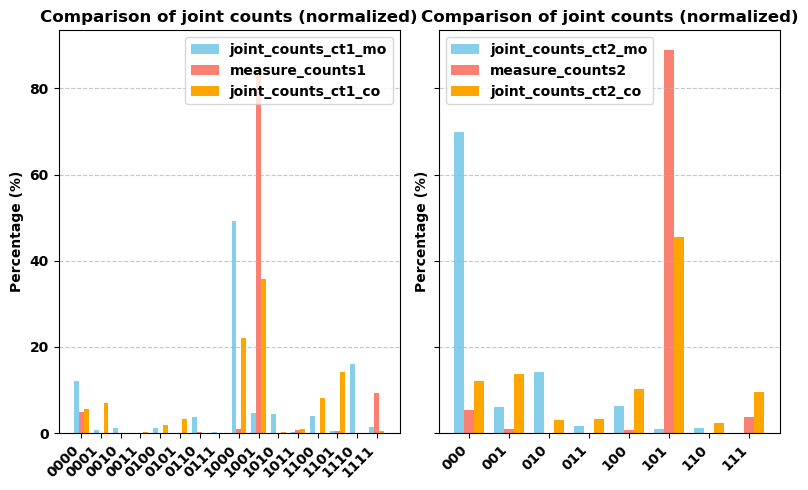

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (3 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.5586', '2.6243', '2.2616']
CRX Angle Optimization took: 8.97 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.5586', '2.6243', '2.2616']
  Minimum Combined KL Divergence with Optimized CRX: 0.761259


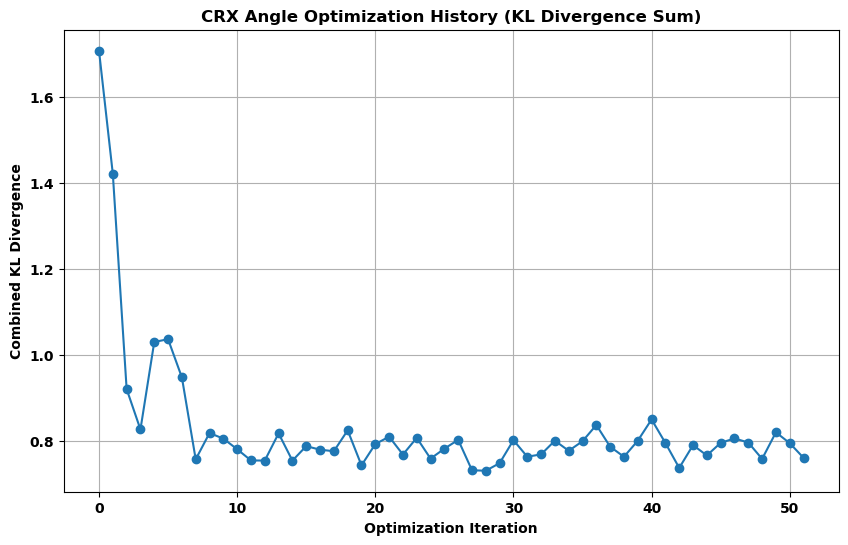


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                     ├»
«              │                                                                                                                                                      │»
«         q_1: ┤1                                                                                                                              

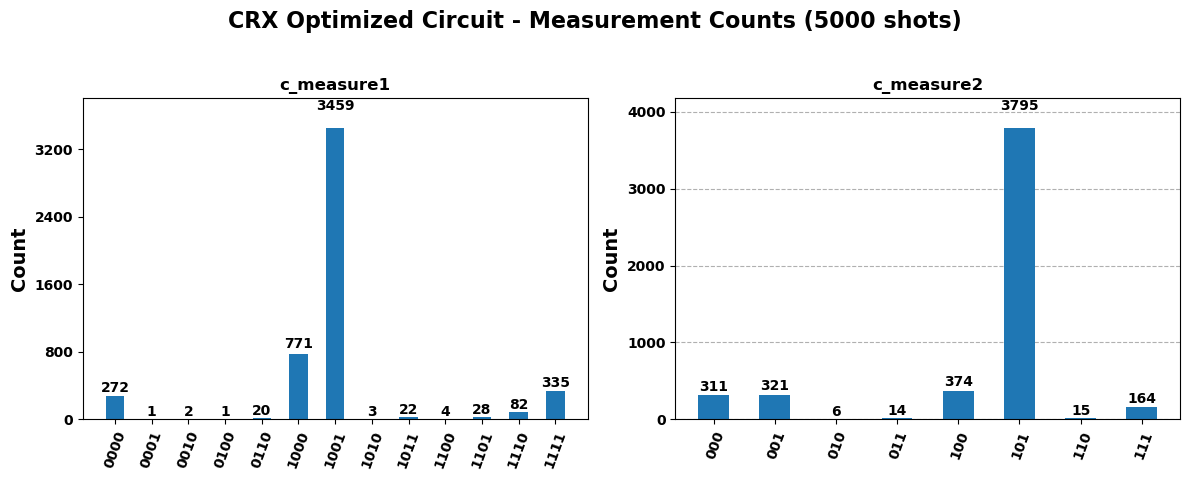

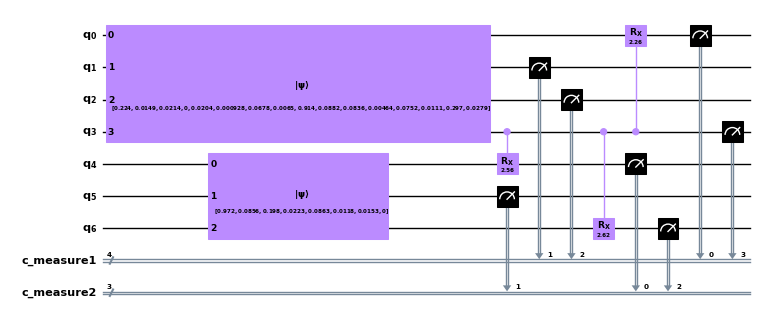

In [19]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.5)

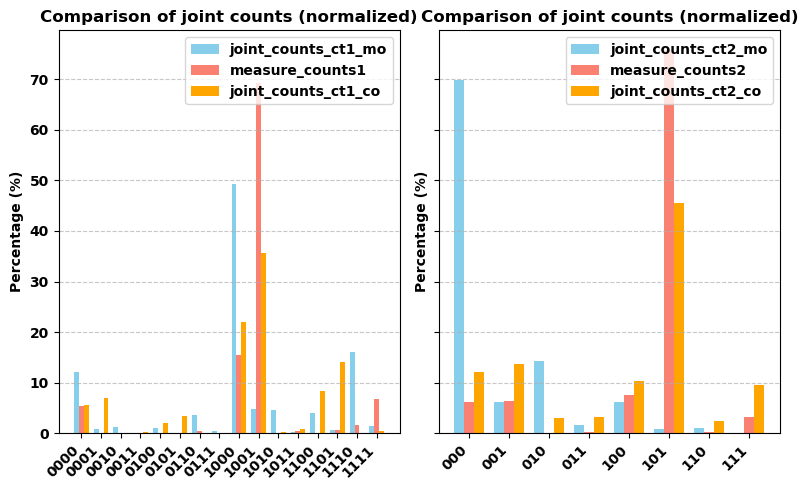

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts_anglkes.svg')



--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---


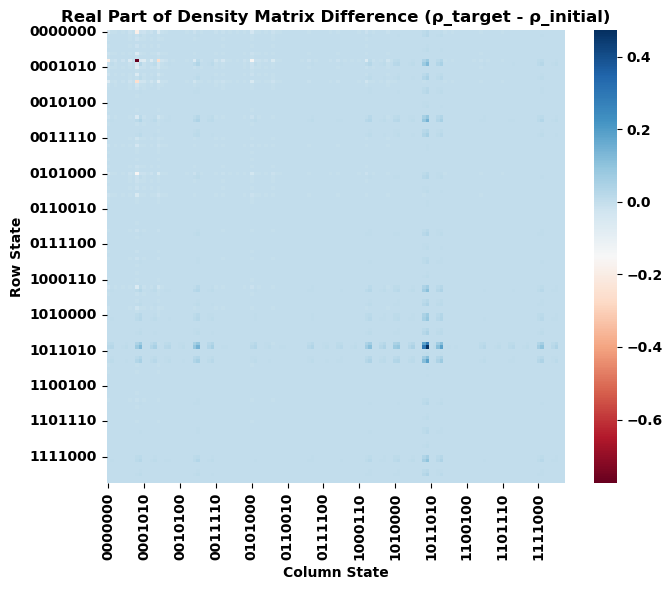


--- CNOT Candidate Analysis Summary ---
System has 7 qubits.
Total possible CNOTs (brute-force): 42
Number of refined CNOT candidates found: 6
---------------------------------------

Initial KL Divergence (no CNOTs): 4.749442

--- Building KL Divergence Matrix (6x6) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 30
--- KL Divergence Matrix Built ---


In [21]:
from quantum_functions import build_kl_divergence_matrix_interaction

np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)
    
kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_interaction(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= 0.4, 
    include_single_cnot_kl=True
)

In [22]:
from quantum_functions import kl_to_qubo_matrix

# Creating Q matrix 
kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)

In [23]:
from qiskit_optimization import QuadraticProgram
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Assume kl_div_mat_qubo is your 42x42 NumPy array

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# Set the objective function to minimize the cost defined by the QUBO matrix
# The matrix must be passed as the 'quadratic' term.
qp.minimize(quadratic=kl_div_mat_qubo)

# --- 2. Convert the QUBO to an Ising Hamiltonian ---
# The Ising Converter performs the necessary transformation (x = (1 - Z)/2)
hamiltonian, offset = qp.to_ising()
print(offset)
print(hamiltonian)

-1.2286898002604456
SparsePauliOp(['IIIIIZ', 'IIIIZZ', 'IIIIZI', 'IIIZIZ', 'IIIZII', 'IIZIIZ', 'IIZIII', 'IZIIIZ', 'IZIIII', 'ZIIIIZ', 'ZIIIII', 'IIIZZI', 'IIZIZI', 'IZIIZI', 'ZIIIZI', 'IIZZII', 'IZIZII', 'ZIIZII', 'IZZIII', 'ZIZIII', 'ZZIIII'],
              coeffs=[-6.08048514e-02+0.j,  1.67920468e-02+0.j,  5.59437805e-01+0.j,
 -5.20965296e-03+0.j,  8.20028873e-01+0.j,  1.21290791e-02+0.j,
  5.34578810e-01+0.j,  2.30683760e-02+0.j, -1.31058306e-02+0.j,
  3.65197124e-02+0.j, -3.49041111e-02+0.j, -1.42571116e-02+0.j,
 -2.71463496e-02+0.j, -2.76847756e-02+0.j,  5.19182314e-03+0.j,
 -5.89289861e-01+0.j,  1.46607815e-04+0.j, -1.43131685e-04+0.j,
 -6.68206862e-03+0.j,  3.49750873e-03+0.j, -3.47309741e-03+0.j])


In [24]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
import numpy as np

# --- 1. Configuration (Example values) ---
num_qubits = kl_div_mat_qubo.shape[0]
reps = 1
entanglement = 'circular'  # linear sca circular pairwise reverse_linear full

# --- 2. Ansatz Creation ---
ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)

basis_gates = ['u', 'cx'] 
# 2. Transpile the circuit to decompose it into the basis gates.
expanded_ansatz = transpile(
    ansatz, 
    basis_gates = basis_gates, 
    optimization_level = 0  # Set to 0 to minimize changes beyond decomposition
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
backend = AerSimulator()
#backend = service.least_busy(operational=True, simulator=False)
expanded_ansatz.draw()

C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_6348\4128365459.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)


global phase: -θ[6]/2 - θ[7]/2 - θ[8]/2 - θ[9]/2 - θ[10]/2 - θ[11]/2 - θ[18]/2 - θ[19]/2 - θ[20]/2 - θ[21]/2 - θ[22]/2 - θ[23]/2
     ┌─────────────┐┌─────────────┐ ┌───┐     ┌──────────────┐┌──────────────┐»
q_0: ┤ U(θ[0],0,0) ├┤ U(0,0,θ[6]) ├─┤ X ├──■──┤ U(θ[12],0,0) ├┤ U(0,0,θ[18]) ├»
     ├─────────────┤├─────────────┤ └─┬─┘┌─┴─┐└──────────────┘├──────────────┤»
q_1: ┤ U(θ[1],0,0) ├┤ U(0,0,θ[7]) ├───┼──┤ X ├───────■────────┤ U(θ[13],0,0) ├»
     ├─────────────┤├─────────────┤   │  └───┘     ┌─┴─┐      └──────────────┘»
q_2: ┤ U(θ[2],0,0) ├┤ U(0,0,θ[8]) ├───┼────────────┤ X ├─────────────■────────»
     ├─────────────┤├─────────────┤   │            └───┘           ┌─┴─┐      »
q_3: ┤ U(θ[3],0,0) ├┤ U(0,0,θ[9]) ├───┼────────────────────────────┤ X ├──────»
     ├─────────────┤├─────────────┴┐  │                            └───┘      »
q_4: ┤ U(θ[4],0,0) ├┤ U(0,0,θ[10]) ├──┼───────────────────────────────────────»
     ├─────────────┤├──────────────┤  │                                       »
q_5: ┤ U(θ[5],0,0) ├┤ U(0,0,θ[11]) ├──■───────────────────────────────────────»
     └─────────────┘└──────────────┘                                          »
«                                                                     
«q_0: ────────────────────────────────────────────────────────────────
«     ┌──────────────┐                                                
«q_1: ┤ U(0,0,θ[19]) ├────────────────────────────────────────────────
«     ├──────────────┤┌──────────────┐                                
«q_2: ┤ U(θ[14],0,0) ├┤ U(0,0,θ[20]) ├────────────────────────────────
«     └──────────────┘├──────────────┤┌──────────────┐                
«q_3: ───────■────────┤ U(θ[15],0,0) ├┤ U(0,0,θ[21]) ├────────────────
«          ┌─┴─┐      └──────────────┘├──────────────┤┌──────────────┐
«q_4: ─────┤ X ├─────────────■────────┤ U(θ[16],0,0) ├┤ U(0,0,θ[22]) ├
«          └───┘           ┌─┴─┐      ├──────────────┤├──────────────┤
«q_5: ─────────────────────┤ X ├──────┤ U(θ[17],0,0) ├┤ U(0,0,θ[23]) ├
«                          └───┘      └──────────────┘└──────────────┘

Starting optimization with method: COBYLA
Iteration 0: Current cost: -0.0035604257047885538
Iteration 20: Current cost: -0.0022040168157112412
Iteration 40: Current cost: -1.0815867370760126
Iteration 60: Current cost: -1.711901112676688
Iteration 80: Current cost: -1.8430135151733933
Iteration 100: Current cost: -2.199243687939001
Iteration 200: Current cost: -2.3551015382746927

Optimization Result:
 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -2.4060250671447054
       x: [ 2.343e+00  1.711e+00 ...  1.007e+00  7.181e-01]
    nfev: 200
   maxcv: 0.0

Final Energy: -2.4060250671447054

Optimized Full Parameters:
  θ[0]: 2.3431390631485876
  θ[1]: 1.711323034879105
  θ[2]: 1.465933062988918
  θ[3]: 1.5887915856485275
  θ[4]: 1.647725820550707
  θ[5]: 1.4513811791925455
  θ[6]: 1.4223020194899612
  θ[7]: 0.49187165930919313
  θ[8]: -0.10087870604927371
  θ[9]: 0.13647062664700144
  θ[10]: 0.043023279659540226
  θ[11]: 1.090460

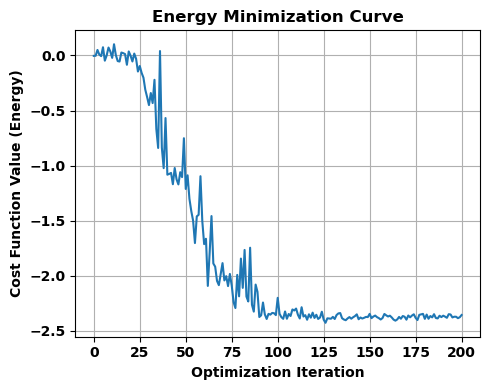

In [25]:
from quantum_functions import vqe_solver
result, optimized_params, cost_values = vqe_solver(
    expanded_ansatz,
    hamiltonian,
    backend,
    optimizer_method="COBYLA", # COBYLA | L-BFGS-B 
    niter= 200
)

# Plot the cost function values
plt.figure(figsize=(5, 4))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
#plt.savefig('vqe_opt_curve_qmat.svg', bbox_inches='tight')
plt.show()    

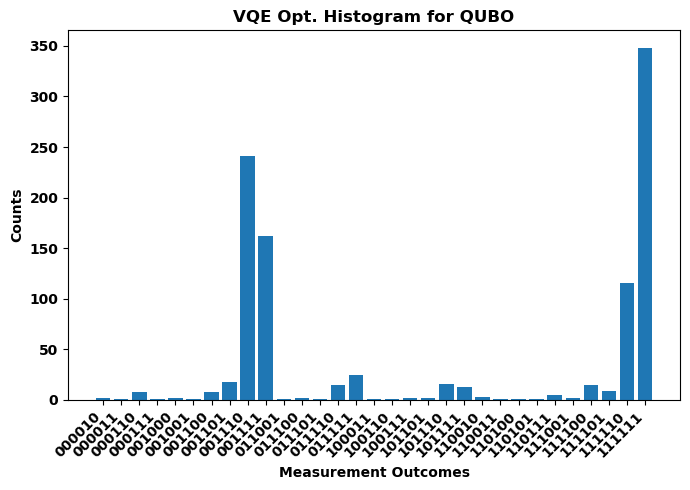

In [26]:
from quantum_functions import evaluate_and_plot_ansatz

counts, bound_circuit = evaluate_and_plot_ansatz(
    ansatz=expanded_ansatz, 
    params=optimized_params, 
    backend=backend,
    shots=1024,
    title="VQE Opt. Histogram for QUBO",
    show_plot=True  # Explicitly show the plot
)
#bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [27]:
# ==============================================================================
# --- CALL THE VQE HYBRID SEARCH AND DISPLAY RESULTS ---
# ==============================================================================
from quantum_functions import run_vqe_hybrid_search
# Assume these variables are defined from your previous notebook cells:
# - counts: The dictionary of measurement results from your VQE run.
# - initial_cnot_config: The full list of CNOT candidates used for the VQE QUBO.
# - circ1, circ2: Your two base quantum circuits.
# - normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo: Initial states.
# - normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co: Target states.
# - thresh: The threshold for density matrix analysis (if used).

# Call the main search function
best_cnot_sequence, min_kl_sum, best_solution_rank = run_vqe_hybrid_search(
    vqe_counts=counts,
    initial_cnot_config=initial_cnot_config,
    circ1=circ1,
    circ2=circ2,
    state_probs_initial1=normalized_joint_counts_ct1_mo,
    state_probs_initial2=normalized_joint_counts_ct2_mo,
    state_vec_probs_target1=normalized_joint_counts_ct1_co,
    state_vec_probs_target2=normalized_joint_counts_ct2_co,
    num_solutions_to_test=3,
    nshots=5000,
    threshold=thresh,
    kl_tol=0.1,
    ratio_kl_tol=0.6,
    max_greedy_depth=30
)

# --- FINAL SUMMARY: Display the Overall Best Solution ---
print("\n" + "="*60)
print("--- OVERALL BEST SOLUTION AFTER HYBRID SEARCH ---")
print("="*60)

if best_solution_rank is not None:
    print(f"The best solution originated from the VQE's result at Rank {best_solution_rank}.")
    print(f"\nFinal optimal CNOT sequence found with {len(best_cnot_sequence)} CNOTs:")
    if best_cnot_sequence:
        for cnot in best_cnot_sequence:
            print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    else:
        print("  (The best solution found was to use no CNOTs)")

    print(f"\nWith a minimum combined KL Divergence of: {min_kl_sum:.6f}")

    # Re-create and draw the final, absolute best circuit
    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("No VQE solution led to a greedy search result that improved upon the initial baseline.")
    print("The best configuration is the baseline circuit with no CNOTs.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))

print("="*60 + "\n")

--- Preparing to test Top 3 VQE solutions in REVERSE order ---

--- Testing VQE Solution (Rank 3/3) ---
This VQE Solution corresponds to a candidate subset of 4 CNOTs:
  q[0] -> q[3]
  q[3] -> q[0]
  q[3] -> q[4]
  q[3] -> q[6]

Setting number of greedy search epochs to 4 (one for each candidate).

--- Starting Multi-Epoch Refined Search ---

--- Using provided CNOT candidate list for the search. ---
Number of candidates to be searched: 4
Initial KL divergence (baseline): 4.772028

--- Starting Epoch 1/4 (Addition) with CNOT: (3, 0) (KL: 3.718154) ---
    --> Found a better KL on this path: 3.291250 at depth 2 with added CNOT (3, 4)
    --> Found a better KL on this path: 1.109045 at depth 3 with added CNOT (3, 6)
  Epoch 1 best KL Sum: 1.109045
  --> Epoch 1 found a new overall best KL Sum: 1.109045

--- Starting Epoch 2/4 (Addition) with CNOT: (3, 4) (KL: 4.377288) ---
    --> Found a better KL on this path: 2.155265 at depth 2 with added CNOT (3, 6)
    --> Found a better KL on this


--- Running circuit for: VQE + Epoch search Optimized Circuit ---
Counts for c_measure1: {'1001': 4208, '1111': 424, '0000': 241, '0110': 22, '1101': 23, '1011': 38, '1110': 4, '1000': 33, '0010': 2, '0100': 5}
Counts for c_measure2: {'101': 4482, '111': 186, '000': 259, '001': 25, '100': 33, '010': 9, '110': 3, '011': 3}


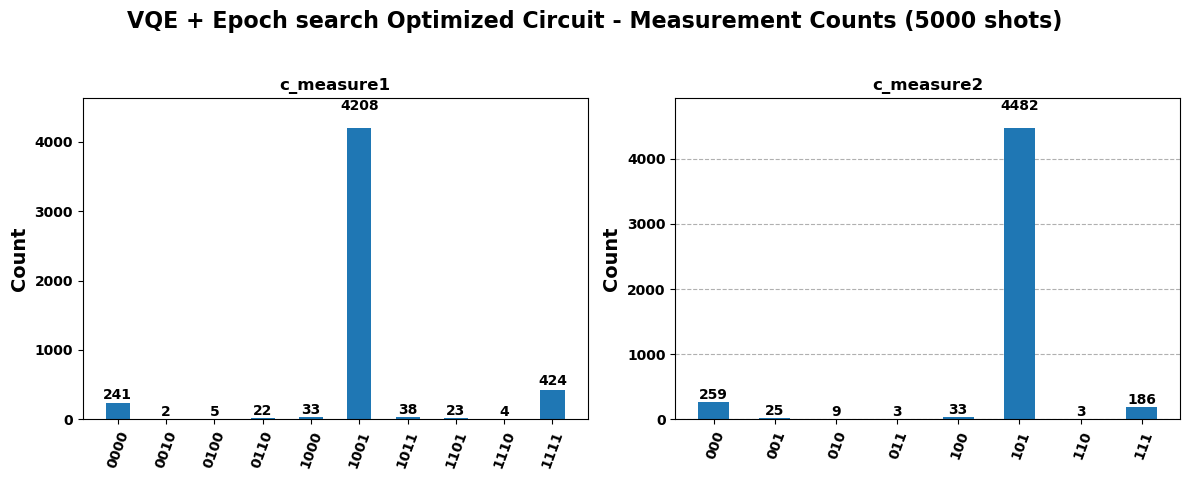

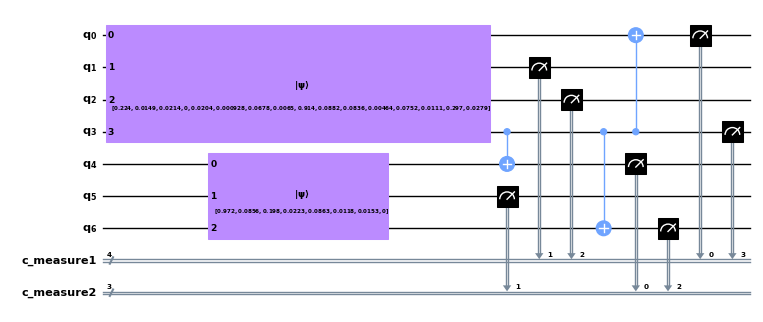

In [28]:
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_best_circuit_search, nshots=5000, title_prefix="VQE + Epoch search Optimized Circuit")
final_best_circuit_search
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

In [40]:
# ==============================================================================
# --- STAGE 1: RUN QAOA TO GET CANDIDATE SOLUTIONS ---
# ==============================================================================
# This is your existing QAOA setup code
import numpy as np
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals
num_qubits = kl_div_mat_qubo.shape[0]
# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")
# Add binary variables: one for each CNOT candidate (0 to 41)
for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')
qp.minimize(quadratic=kl_div_mat_qubo)
# kl_vec = np.diag(kl_div_mat_qubo).copy()
# np.fill_diagonal(kl_div_mat_qubo, 0.0)
#qp.minimize(quadratic=kl_div_mat_qubo, linear=kl_vec)
op, offset = qp.to_ising()
print("offset: {}".format(offset))
print(qp.prettyprint())
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2
algorithm_globals.random_seed = 10598
pass_manager = generate_preset_pass_manager(optimization_level=2, backend=AerSimulator())
qaoa_set = QAOA(
    sampler=SamplerV2(seed=123, default_shots=2000),
    optimizer=COBYLA(maxiter=200),
    initial_point=[1, 1],
    pass_manager=pass_manager,
    reps=1
)
meo_set = MinimumEigenOptimizer(qaoa_set)
qaoa_result = meo_set.solve(qp)
print(qaoa_result.prettyprint())


offset: -1.2286898002604456
Problem name: CnotOptimization

Minimize
  -0.04498941997598216*x0^2 + 0.06716818733505026*x0*x1
  - 0.020838611857410427*x0*x2 + 0.04851631623977326*x0*x3
  + 0.09227350411036195*x0*x4 + 0.1460788495363996*x0*x5
  - 1.0246668767873919*x1^2 - 0.05702844639295135*x1*x2
  - 0.10858539825283753*x1*x3 - 0.11073910222129868*x1*x4
  + 0.020767292569592755*x1*x5 - 0.4225514457390034*x2^2
  - 2.357159444827426*x2*x3 + 0.0005864312608006017*x2*x4
  - 0.0005725267407354906*x2*x5 + 0.1458257625969921*x3^2
  - 0.02672827448260673*x3*x4 + 0.013990034903336834*x3*x5
  + 0.05546157665515761*x4^2 - 0.013892389648062498*x4*x5
  - 0.013377408036657101*x5^2

Subject to
  No constraints

  Binary variables (6)
    x0 x1 x2 x3 x4 x5

objective function value: -3.905585218190565
variable values: x0=0.0, x1=1.0, x2=1.0, x3=1.0, x4=1.0, x5=0.0
status: SUCCESS


In [45]:
# CORRECTED HELPER FUNCTION
from qiskit_optimization.algorithms import SolutionSample 
from typing import List, Dict

def convert_qaoa_samples_to_counts(
    samples: List[SolutionSample], 
    total_shots_equivalent: int = 10000
) -> Dict[str, int]:
    """
    Converts a list of QAOA SolutionSample objects into a VQE-style counts dictionary.

    This is necessary to use the QAOA results with functions designed for VQE/Sampler output.
    It preserves the relative probabilities of the solutions by converting them to integer counts.

    Args:
        samples (List[SolutionSample]): The list of samples from a Qiskit Optimization result.
        total_shots_equivalent (int): A scaling factor to convert probabilities into
                                      integer counts. The exact value doesn't matter as
                                      long as it preserves the order.

    Returns:
        Dict[str, int]: A dictionary where keys are big-endian bitstrings and values are
                        the corresponding "counts", compatible with the hybrid search function.
    """
    qaoa_counts = {}
    for s in samples:
        # QAOA sample.x is an array like [1., 0., 1.]. Convert to a string '101'.
        # We reverse it to create a big-endian string '101' -> ...x2x1x0, which is
        # a common Qiskit convention and consistent with our VQE helpers.
        bitstring = "".join(str(int(v)) for v in reversed(s.x))
        
        # Convert the solution's probability to an integer count
        count = int(s.probability * total_shots_equivalent)
        
        # Only add solutions with a non-zero chance
        if count > 0:
            qaoa_counts[bitstring] = count
            
    return qaoa_counts

In [46]:
# ==============================================================================
# --- STAGE 2: CONVERT QAOA RESULTS AND RUN HYBRID SEARCH ---
# ==============================================================================

# 1. Convert the QAOA samples list into a VQE-style counts dictionary
qaoa_counts = convert_qaoa_samples_to_counts(qaoa_result.samples)
print(f"\nConverted QAOA results into a counts dictionary with {len(qaoa_counts)} entries.")

# 2. Call the main hybrid search function, using the QAOA counts as input
best_cnot_sequence, min_kl_sum, best_solution_rank = run_vqe_hybrid_search(
    vqe_counts=qaoa_counts,  # <-- Using the converted QAOA results here!
    initial_cnot_config=initial_cnot_config,
    circ1=circ1,
    circ2=circ2,
    state_probs_initial1=normalized_joint_counts_ct1_mo,
    state_probs_initial2=normalized_joint_counts_ct2_mo,
    state_vec_probs_target1=normalized_joint_counts_ct1_co,
    state_vec_probs_target2=normalized_joint_counts_ct2_co,
    num_solutions_to_test=3,  # We will test the top 3 solutions from QAOA
    nshots=5000,
    threshold=thresh,
    kl_tol=0.1,
    ratio_kl_tol=0.6,
    max_greedy_depth=30,
    min_cnot_depth=1 # You can adjust this as needed
)

# ==============================================================================
# --- STAGE 3: DISPLAY THE FINAL, OVERALL BEST SOLUTION ---
# ==============================================================================
print("\n" + "="*60)
print("--- OVERALL BEST SOLUTION AFTER QAOA + HYBRID SEARCH ---")
print("="*60)

if best_solution_rank is not None:
    print(f"The best solution originated from the QAOA's result at Rank {best_solution_rank}.")
    print(f"\nFinal optimal CNOT sequence found with {len(best_cnot_sequence)} CNOTs:")
    if best_cnot_sequence:
        for cnot in best_cnot_sequence:
            print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    else:
        print("  (The best solution found was to use no CNOTs)")

    print(f"\nWith a minimum combined KL Divergence of: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("No QAOA solution led to a greedy search result that improved upon the initial baseline.")
    print("The best configuration is the baseline circuit with no CNOTs.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))

print("="*60 + "\n")


Converted QAOA results into a counts dictionary with 50 entries.
--- Preparing to test Top 3 VQE solutions in REVERSE order ---

--- Testing VQE Solution (Rank 3/3) ---
This VQE Solution corresponds to a candidate subset of 4 CNOTs:
  q[0] -> q[3]
  q[3] -> q[0]
  q[3] -> q[4]
  q[3] -> q[6]

Setting number of greedy search epochs to 4 (one for each candidate).

--- Starting Multi-Epoch Refined Search ---

--- Using provided CNOT candidate list for the search. ---
Number of candidates to be searched: 4
Initial KL divergence (baseline): 4.789146

--- Starting Epoch 1/4 (Addition) with CNOT: (0, 3) (KL: 4.819736) ---
  Skipping epoch: Single CNOT KL (4.819736) does not improve over baseline (4.789146).

--- Starting Epoch 2/4 (Addition) with CNOT: (3, 6) (KL: 4.847292) ---
  Skipping epoch: Single CNOT KL (4.847292) does not improve over baseline (4.789146).

--- Starting Epoch 3/4 (Addition) with CNOT: (3, 4) (KL: 4.292987) ---
    --> Found a better KL on this path: 2.183854 at depth 


--- Running circuit for: VQE + Epoch search Optimized Circuit ---
Counts for c_measure1: {'1001': 4227, '1000': 35, '1111': 413, '0000': 236, '0110': 23, '1011': 41, '1101': 19, '1110': 2, '0001': 2, '0100': 2}
Counts for c_measure2: {'101': 4496, '000': 245, '111': 177, '100': 41, '001': 28, '010': 11, '011': 1, '110': 1}


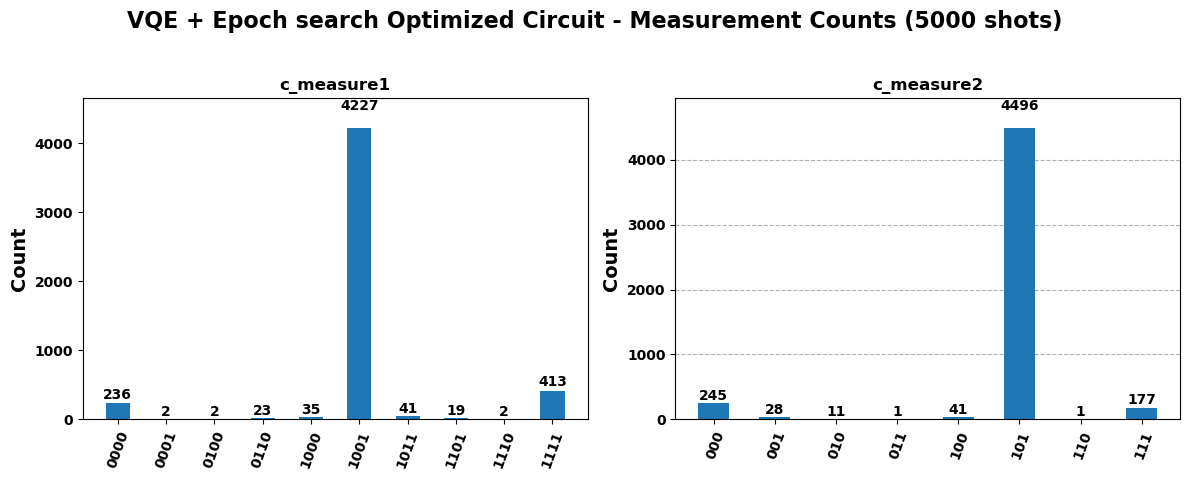

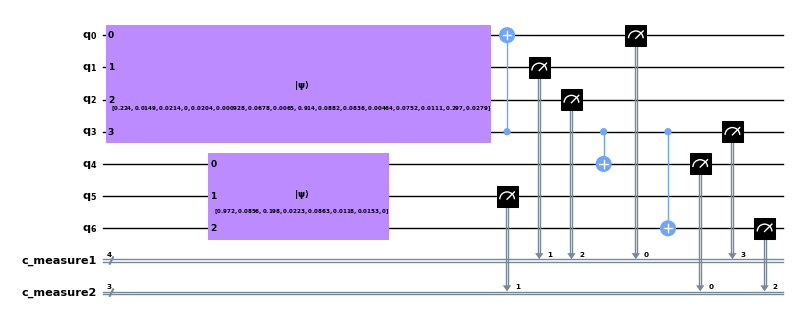

In [47]:
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_best_circuit_search, nshots=5000, title_prefix="VQE + Epoch search Optimized Circuit")
final_best_circuit_search
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)